In [7]:
# # Install Microsoft Visual C++ Build Tools first (if not already installed)
# # Then install dependencies
# !pip install py-cpuinfo
# !pip install ninja

# # Install PyTorch first (CPU version since CUDA is not detected)
# !pip install torch torchvision torchaudio

# # Try installing DeepSpeed with pip and avoid building from source
# !pip install deepspeed --no-cache-dir

# # Install pytorch-gan-metrics
# !pip install pytorch-gan-metrics

In [16]:
import glob
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

# Suppress warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Set random seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Using CPU.")

Physical devices cannot be modified after being initialized


---

# 1. Data Preprocessing

In [15]:
def show_img(img_tensor, nrow, title=""):
    img_tensor = img_tensor.detach().cpu() * 0.5 + 0.5
    img_grid = make_grid(img_tensor, nrow=nrow).permute(1, 2, 0)
    plt.figure(figsize=(18, 8))
    plt.imshow(img_grid)
    plt.axis("off")
    plt.title(title)
    plt.show()

### Augmenting the images.

In [26]:

class CustomTransform:
    def __init__(self, load_dim=286, target_dim=256):
        self.load_dim = load_dim
        self.target_dim = target_dim
        
    def __call__(self, image, stage):
        # Convert to float32 and scale to [0,1] if needed
        image = tf.image.convert_image_dtype(image, tf.float32)
        
        if stage in ["fit", "validate"]:
            # Resize to larger dimension for random cropping
            image = tf.image.resize(image, [self.load_dim, self.load_dim])
            # Random crop
            image = tf.image.random_crop(image, size=[self.target_dim, self.target_dim, 3])
            # Random flip
            image = tf.image.random_flip_left_right(image)
        else:
            # Just resize for test/predict
            image = tf.image.resize(image, [self.target_dim, self.target_dim])
        
        # Scale to [-1, 1] range
        return image * 2 - 1

### Storing the datasets.

In [27]:
class CustomDataset:
    def __init__(self, filenames, transform, stage):
        self.filenames = filenames
        self.transform = transform
        self.stage = stage
        
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        img_path = self.filenames[idx]
        image = tf.io.read_file(img_path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        return self.transform(image, self.stage)

### Iterating through the datasets.

In [ ]:
# DataModule configuration
DM_CONFIG = {
    # Data paths
    "face_train_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\train\\real", "*.*"),
    "face_test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test\\real", "*.*"),
    "sketch_train_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\train\\sketches", "*.*"),
    "sketch_test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test\\sketches", "*.*"),
    "test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test", "*.*"),
    
    # Loader configuration
    "loader_config": {
        "num_parallel_calls": tf.data.AUTOTUNE,
        "prefetch_buffer": tf.data.AUTOTUNE
    },
    
    # Sample configuration
    "sample_size": 5,
    "batch_size": 32
}

# Initialize data module (avoid duplicate batch_size)
config = DM_CONFIG.copy()
config['batch_size'] = 5  # Override batch size for sample
dm_sample = CustomDataModule(**config)
dm_sample.setup("fit")

# Get training datasets
train_datasets = dm_sample.train_dataloader()

# Helper function to display images
def show_img(images, title=None):
    """Display a grid of images"""
    if isinstance(images, dict):
        images = images['data']
        
    batch_size = images.shape[0]
    cols = min(5, batch_size)
    rows = (batch_size + cols - 1) // cols
    
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(batch_size):
        plt.subplot(rows, cols, i + 1)
        # Denormalize if needed
        img = images[i].numpy()
        img = (img + 1) / 2 if img.min() < 0 else img
        plt.imshow(img)
        plt.axis('off')
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Display sample images
for name, dataset in train_datasets.items():
    batch = next(iter(dataset))
    show_img(batch, title=f"Augmented {name.capitalize()}")

Physical devices cannot be modified after being initialized


In [29]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    return image

In [31]:
def create_dataset(filenames, transform, stage, batch_size, shuffle=True):
    def generator():
        for filename in filenames:
            yield CustomDataset([filename], transform, stage)[0]
    
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32)
    )  # Added missing parenthesis here
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [43]:
import tensorflow as tf
import glob
import os

class CustomTransform:
    def __init__(self, load_dim=286, crop_dim=256):
        self.load_dim = load_dim
        self.crop_dim = crop_dim
    
    def __call__(self, image, stage):
        """Apply transformations to the image"""
        # Ensure image has proper shape
        image.set_shape([None, None, 3])
        
        # Convert to float32 and normalize to [-1, 1]
        image = tf.cast(image, tf.float32)
        image = (image / 127.5) - 1.0
        
        # Resize and crop
        image = tf.image.resize(image, [self.load_dim, self.load_dim])
        
        if stage == "fit":
            # Random crop during training
            image = tf.image.random_crop(image, [self.crop_dim, self.crop_dim, 3])
            # Random flip for augmentation
            image = tf.image.random_flip_left_right(image)
        else:
            # Center crop for validation/testing
            image = tf.image.central_crop(image, self.crop_dim / self.load_dim)
        
        return image

class CustomDataModule:
    def __init__(
        self,
        face_train_dir,
        face_test_dir,
        sketch_train_dir, 
        sketch_test_dir,
        test_dir,
        loader_config,
        sample_size,
        batch_size
    ):
        self.loader_config = loader_config
        self.sample_size = sample_size
        self.batch_size = batch_size       
        
        # Store file paths
        self.face_train_filenames = sorted(glob.glob(face_train_dir))
        self.face_test_filenames = sorted(glob.glob(face_test_dir))
        self.sketch_train_filenames = sorted(glob.glob(sketch_train_dir))
        self.sketch_test_filenames = sorted(glob.glob(sketch_test_dir))
        self.test_file = sorted(glob.glob(test_dir))
        
        # Initialize transform
        self.transform = CustomTransform()
        
        print(f"Found {len(self.face_train_filenames)} face training images")
        print(f"Found {len(self.sketch_train_filenames)} sketch training images")
    
    def _load_and_transform(self, path, stage):
        """Load and transform a single image"""
        # Read image file
        img = tf.io.read_file(path)
        # Decode image
        img = tf.image.decode_jpeg(img, channels=3)
        # Apply transformations
        img = self.transform(img, stage)
        return img
    
    
    def _create_dataset(self, filenames, stage):
        """Create a TensorFlow dataset from filenames"""
        if not filenames:
            raise ValueError(f"No files found for {stage} dataset")
            
        # Create dataset from filenames
        dataset = tf.data.Dataset.from_tensor_slices(filenames)
        
        # Map loading and transformation function
        dataset = dataset.map(
            lambda x: self._load_and_transform(x, stage),
            num_parallel_calls=self.loader_config.get('num_parallel_calls', tf.data.AUTOTUNE)
        )
        
        return dataset

    def setup(self, stage=None):
        """Setup datasets for training, validation and testing"""
        if stage == "fit" or stage is None:
            # Create training datasets
            self.train_face = self._create_dataset(self.face_train_filenames, "fit")
            self.train_sketch = self._create_dataset(self.sketch_train_filenames, "fit")
            
            # Create validation datasets
            self.test_face = self._create_dataset(self.face_test_filenames, "test")
            self.test_sketch = self._create_dataset(self.sketch_test_filenames, "test")
            
        if stage == "test" or stage is None:
            # Create test dataset
            self.test = self._create_dataset(self.test_file, "test")    
    def _load_and_transform(self, path, stage):
        """Load and transform images"""
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3)
        img = self.transform(img, stage)
        return img
    
    def train_dataloader(self):
        face_dataset = self.train_face.shuffle(
            1000, reshuffle_each_iteration=True
        ).batch(
            self.batch_size
        ).prefetch(tf.data.AUTOTUNE)
        
        sketch_dataset = self.train_sketch.shuffle(
            1000, reshuffle_each_iteration=True
        ).batch(
            self.batch_size
        ).prefetch(tf.data.AUTOTUNE)
        
        return {"face": face_dataset, "sketch": sketch_dataset}
    
    def val_dataloader(self):
        face_dataset = self.test_face.shuffle(
            1000, reshuffle_each_iteration=True
        ).batch(
            self.batch_size
        ).prefetch(tf.data.AUTOTUNE)
        
        sketch_dataset = self.test_sketch.shuffle(
            1000, reshuffle_each_iteration=True
        ).batch(
            self.batch_size
        ).prefetch(tf.data.AUTOTUNE)
        
        return {"face": face_dataset, "sketch": sketch_dataset}
    
    def test_dataloader(self):
        return self.test.batch(
            self.sample_size
        ).prefetch(tf.data.AUTOTUNE)
    
    def predict_dataloader(self):
        return self.test_sketch.batch(
            self.batch_size
        ).prefetch(tf.data.AUTOTUNE)

# Example usage:
def create_data_module(config):
    return CustomDataModule(**config)

Found 2790 face training images
Found 2790 sketch training images


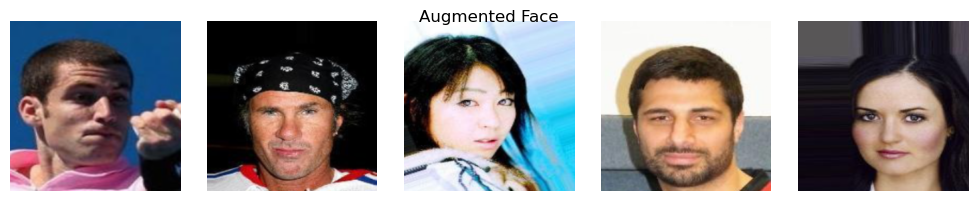

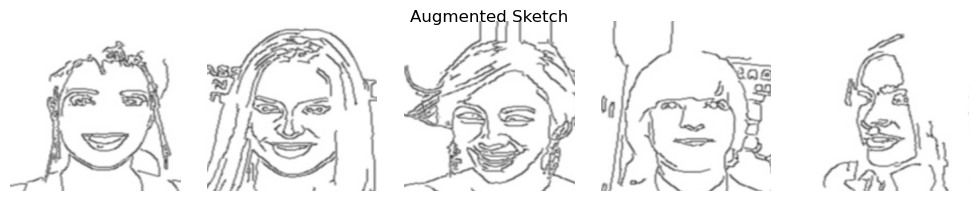

In [44]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# DataModule configuration
DM_CONFIG = {
    # Data paths
    "face_train_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\train\\real", "*.*"),
    "face_test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test\\real", "*.*"),
    "sketch_train_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\train\\sketches", "*.*"),
    "sketch_test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test\\sketches", "*.*"),
    "test_dir": os.path.join("E:\\SketchToFace\\ProcessedImages\\test", "*.*"),
    
    # Loader configuration
    "loader_config": {
        "num_parallel_calls": tf.data.AUTOTUNE,
        "prefetch_buffer": tf.data.AUTOTUNE
    },
    
    # Sample configuration
    "sample_size": 5,
    "batch_size": 32
}

def show_img(images, title=None):
    """Display a grid of images from TensorFlow dataset"""
    try:
        # Handle different input types
        if isinstance(images, dict):
            images = images['data']
        if isinstance(images, tf.Tensor):
            images = images.numpy()
            
        # Get batch size and calculate grid dimensions
        batch_size = images.shape[0]
        cols = min(5, batch_size)
        rows = (batch_size + cols - 1) // cols
        
        # Create figure
        plt.figure(figsize=(cols * 2, rows * 2))
        
        # Display images
        for i in range(batch_size):
            plt.subplot(rows, cols, i + 1)
            # Denormalize if needed
            img = images[i]
            if img.min() < 0:
                img = (img + 1) / 2
            img = tf.clip_by_value(img, 0, 1)
            plt.imshow(img)
            plt.axis('off')
            
        if title:
            plt.suptitle(title)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error displaying images: {str(e)}")

# Initialize data module with sample batch size
try:
    config = {k: v for k, v in DM_CONFIG.items() if k != 'batch_size'}
    config['batch_size'] = 5  # Sample batch size
    
    dm_sample = CustomDataModule(**config)
    dm_sample.setup("fit")
    
    train_datasets = dm_sample.train_dataloader()
    for name, dataset in train_datasets.items():
        batch = next(iter(dataset))
        show_img(batch, title=f"Augmented {name.capitalize()}")
        
except Exception as e:
    print(f"Error: {str(e)}")

---

# 2. Building CycleGAN Architecture

### Downsampling blocks.

### Upsampling blocks.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

class Upsampling(tf.keras.layers.Layer):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=4,
        stride=2,
        padding='same',
        output_padding=0,
        dropout=False,
    ):
        super().__init__()
        self.block = [
            layers.Conv2DTranspose(
                filters=out_channels,
                kernel_size=kernel_size,
                strides=stride,
                padding=padding,
                use_bias=False
            ),
            layers.BatchNormalization(),
        ]
        
        if dropout:
            self.block.append(layers.Dropout(0.5))
        self.block.append(layers.ReLU())
        
    def call(self, x):
        for layer in self.block:
            x = layer(x)
        return x

class Downsampling(tf.keras.layers.Layer):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=4,
        stride=2,
        padding='same',
        norm=True,
        lrelu=True,
    ):
        super().__init__()
        self.block = [
            layers.Conv2D(
                filters=out_channels,
                kernel_size=kernel_size,
                strides=stride,
                padding=padding,
                use_bias=not norm
            )
        ]
        
        if norm:
            self.block.append(layers.BatchNormalization())
        
        if lrelu is not None:
            self.block.append(
                layers.LeakyReLU(alpha=0.2) if lrelu else layers.ReLU()
            )
    
    def call(self, x):
        for layer in self.block:
            x = layer(x)
        return x

### Residual blocks.

In [5]:
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, Model

class ResBlock(tf.keras.layers.Layer):
    def __init__(self, in_channels, kernel_size=3, padding='same'):
        super().__init__()
        self.block = [
            layers.ZeroPadding2D(padding),
            Downsampling(in_channels, in_channels,
                        kernel_size=kernel_size, stride=1, padding='valid', lrelu=False),
            layers.ZeroPadding2D(padding),
            Downsampling(in_channels, in_channels,
                        kernel_size=kernel_size, stride=1, padding='valid', lrelu=None)
        ]
        
    def call(self, x):
        return x + self._forward(x)
    
    def _forward(self, x):
        for layer in self.block:
            x = layer(x)
        return x

### Building the generator.

In [6]:


class UNetGenerator(tf.keras.Model):
    def __init__(self, hid_channels, in_channels, out_channels):
        super().__init__()
        # Downsampling path
        self.down_layers = [
            Downsampling(in_channels, hid_channels, norm=False),
            Downsampling(hid_channels, hid_channels*2),
            Downsampling(hid_channels*2, hid_channels*4),
            Downsampling(hid_channels*4, hid_channels*8),
            Downsampling(hid_channels*8, hid_channels*8),
            Downsampling(hid_channels*8, hid_channels*8),
            Downsampling(hid_channels*8, hid_channels*8),
            Downsampling(hid_channels*8, hid_channels*8, norm=False)
        ]
        
        # Upsampling path
        self.up_layers = [
            Upsampling(hid_channels*8, hid_channels*8, dropout=True),
            Upsampling(hid_channels*16, hid_channels*8, dropout=True),
            Upsampling(hid_channels*16, hid_channels*8, dropout=True),
            Upsampling(hid_channels*16, hid_channels*8),
            Upsampling(hid_channels*16, hid_channels*4),
            Upsampling(hid_channels*8, hid_channels*2),
            Upsampling(hid_channels*4, hid_channels)
        ]
        
        # Final feature block
        self.feature_block = [
            layers.Conv2DTranspose(out_channels, kernel_size=4, strides=2,
                                 padding='same'),
            layers.Activation('tanh')
        ]
    
    def call(self, x):
        skips = []
        # Downsampling and store skip connections
        for down in self.down_layers:
            x = down(x)
            skips.append(x)
        
        # Remove last skip connection and reverse list
        skips = skips[:-1][::-1]
        
        # Upsampling with skip connections
        for up, skip in zip(self.up_layers, skips):
            x = up(x)
            x = tf.concat([x, skip], axis=-1)
        
        # Final processing
        for layer in self.feature_block:
            x = layer(x)
        return x

class ResNetGenerator(tf.keras.Model):
    def __init__(self, hid_channels, in_channels, out_channels, num_resblocks):
        super().__init__()
        
        self.model_layers = [
            # Downsampling path
            layers.ZeroPadding2D(3),
            Downsampling(in_channels, hid_channels,
                        kernel_size=7, stride=1, padding='valid', lrelu=False),
            Downsampling(hid_channels, hid_channels*2, kernel_size=3, lrelu=False),
            Downsampling(hid_channels*2, hid_channels*4, kernel_size=3, lrelu=False),
            
            # Residual blocks
            *[ResBlock(hid_channels*4) for _ in range(num_resblocks)],
            
            # Upsampling path
            Upsampling(hid_channels*4, hid_channels*2, kernel_size=3),
            Upsampling(hid_channels*2, hid_channels, kernel_size=3),
            layers.ZeroPadding2D(3),
            layers.Conv2D(out_channels, kernel_size=7, strides=1, padding='valid'),
            layers.Activation('tanh')
        ]
    
    def call(self, x):
        for layer in self.model_layers:
            x = layer(x)
        return x

def get_gen(gen_name, hid_channels, num_resblocks, in_channels=3, out_channels=3):
    """Factory function to create generators"""
    if gen_name == "unet":
        return UNetGenerator(hid_channels, in_channels, out_channels)
    elif gen_name == "resnet":
        return ResNetGenerator(hid_channels, in_channels, out_channels, num_resblocks)
    else:
        raise NotImplementedError(f"Generator name '{gen_name}' not recognized.")

### Building the discriminator.

In [8]:
import tensorflow as tf
import numpy as np

class Discriminator(tf.keras.Model):
    def __init__(self, hid_channels, in_channels=3):
        super().__init__()
        self.model_layers = [
            Downsampling(in_channels, hid_channels, norm=False),  # 64x128x128
            Downsampling(hid_channels, hid_channels*2),  # 128x64x64
            Downsampling(hid_channels*2, hid_channels*4),  # 256x32x32
            Downsampling(hid_channels*4, hid_channels*8, stride=1),  # 512x31x31
            layers.Conv2D(1, kernel_size=4, padding='same')  # 1x30x30
        ]
    
    def call(self, x):
        for layer in self.model_layers:
            x = layer(x)
        return x

### Image buffer.

In [9]:


class ImageBuffer:
    def __init__(self, buffer_size):
        self.buffer_size = buffer_size
        if self.buffer_size > 0:
            # the current capacity of the buffer
            self.curr_cap = 0
            # initialize buffer as empty list
            self.buffer = []
    
    def __call__(self, imgs):
        # the buffer is not used
        if self.buffer_size == 0:
            return imgs
        
        return_imgs = []
        for img in imgs:
            # Add batch dimension if needed
            img = tf.expand_dims(img, axis=0)
            
            # fill buffer to maximum capacity
            if self.curr_cap < self.buffer_size:
                self.curr_cap += 1
                self.buffer.append(img)
                return_imgs.append(img)
            else:
                p = np.random.uniform(low=0., high=1.)
                
                # swap images between input and buffer with probability 0.5
                if p > 0.5:
                    idx = np.random.randint(low=0, high=self.buffer_size)
                    tmp = tf.identity(self.buffer[idx])  # Create a copy
                    self.buffer[idx] = img
                    return_imgs.append(tmp)
                else:
                    return_imgs.append(img)
        
        # Concatenate along batch dimension
        return tf.concat(return_imgs, axis=0)

### CycleGAN.

In [52]:
import tensorflow as tf
import tensorflow_addons as tfa

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

# Define optimizer creator function
def create_optimizer():
    base_optimizer = tf.keras.optimizers.Adam(
        learning_rate=2e-4,
        beta_1=0.5,
        beta_2=0.999
    )
    if gpus:
        return tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)
    return base_optimizer

MODEL_CONFIG = {
    # Generator configuration
    "gen_name": "unet",  # types: 'unet', 'resnet'
    "num_resblocks": 6,
    "hid_channels": 64,
    
    # Optimizer configuration
    "optimizer": create_optimizer(),
    "lr": 2e-4,
    'optimizer': {
        'learning_rate': 2e-4,
        'beta_1': 0.5,
        'beta_2': 0.999
    },
    
    # Loss weights
    "lambda_idt": 0.5,
    "lambda_cycle": (10.0, 10.0),  # (sketch->face, face->sketch direction)
    
    # Training configuration
    "buffer_size": 100,
    "num_epochs": 3 ,
    "decay_epochs": 3 ,
    
    # Device configuration
    "mixed_precision": bool(gpus),
    "device": "/GPU:0" if gpus else "/CPU:0"
}

# Enable mixed precision if GPU is available
if gpus:
    print("Enabling mixed precision training")
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

GPUs available: 1
Enabling mixed precision training


In [54]:
import tensorflow as tf
import tensorflow_addons as tfa

class CycleGAN(tf.keras.Model):
    def __init__(
        self,
        gen_name,
        num_resblocks,
        hid_channels,
        optimizer,
        lr,
        betas,
        lambda_idt,
        lambda_cycle,
        buffer_size,
        num_epochs,
        decay_epochs,
    ):
        super().__init__()
        self.hparams = {
            'gen_name': gen_name,
            'num_resblocks': num_resblocks,
            'hid_channels': hid_channels,
            'lr': lr,
            'lambda_idt': lambda_idt,
            'lambda_cycle': lambda_cycle,
            'num_epochs': num_epochs,
            'decay_epochs': decay_epochs
        }
        
        # define generators and discriminators
        self.gen_SF = get_gen(gen_name, hid_channels, num_resblocks)
        self.gen_FS = get_gen(gen_name, hid_channels, num_resblocks)
        self.disc_F = Discriminator(hid_channels)
        self.disc_S = Discriminator(hid_channels)
        
        # initialize buffers to store fake images
        self.buffer_fake_F = ImageBuffer(buffer_size)
        self.buffer_fake_S = ImageBuffer(buffer_size)
        
        # Define optimizers
        self.gen_optimizer = tf.keras.optimizers.Adam(lr, beta_1=betas[0], beta_2=betas[1])
        self.disc_optimizer = tf.keras.optimizers.Adam(lr, beta_1=betas[0], beta_2=betas[1])
        
        # Metrics
        self.ssim_metric = tf.image.ssim
        self.psnr_metric = tf.image.psnr
        
        self.current_epoch = tf.Variable(0, trainable=False)
        self.metrics_dict = {}
        
    def call(self, inputs):
        return self.gen_SF(inputs)

    @tf.function
    def init_weights(self):
        # TensorFlow auto-initializes weights, but we can add custom initialization if needed
        for model in [self.gen_SF, self.gen_FS, self.disc_F, self.disc_S]:
            for layer in model.layers:
                if isinstance(layer, tf.keras.layers.Conv2D) or \
                   isinstance(layer, tf.keras.layers.Conv2DTranspose):
                    layer.kernel_initializer = tf.keras.initializers.RandomNormal(0.0, 0.02)
                    if layer.use_bias:
                        layer.bias_initializer = tf.keras.initializers.Zeros()

    def get_lr_scheduler(self):
        initial_learning_rate = self.hparams['lr']
        decay_steps = self.hparams['num_epochs'] - self.hparams['decay_epochs']
        
        def decay_function(epoch):
            if epoch < self.hparams['decay_epochs']:
                return initial_learning_rate
            else:
                decay = 1.0 - (epoch - self.hparams['decay_epochs']) / decay_steps
                return initial_learning_rate * max(0.0, decay)
                
        return tf.keras.callbacks.LearningRateScheduler(decay_function)

    def adv_criterion(self, y_pred, y_true):
        return tf.reduce_mean(tf.square(y_pred - y_true))
    
    def recon_criterion(self, y_pred, y_true):
        return tf.reduce_mean(tf.abs(y_pred - y_true))

    @tf.function
    def train_step(self, batch):
        self.real_S = batch["sketch"]
        self.real_F = batch["face"]

        with tf.GradientTape(persistent=True) as tape:
            # Generate fake images
            self.fake_F = self.gen_SF(self.real_S)
            self.fake_S = self.gen_FS(self.real_F)
            
            # Generate identity images
            self.idt_F = self.gen_SF(self.real_F)
            self.idt_S = self.gen_FS(self.real_S)
            
            # Reconstruct images
            self.recon_F = self.gen_SF(self.fake_S)
            self.recon_S = self.gen_FS(self.fake_F)
            
            # Calculate generator losses
            gen_loss = self.get_gen_loss()
            
            # Calculate discriminator losses
            disc_loss_F = self.get_disc_loss_F()
            disc_loss_S = self.get_disc_loss_S()

        # Update generators
        gen_grads = tape.gradient(gen_loss, 
            self.gen_SF.trainable_variables + self.gen_FS.trainable_variables)
        self.gen_optimizer.apply_gradients(
            zip(gen_grads, self.gen_SF.trainable_variables + self.gen_FS.trainable_variables))

        # Update discriminators
        disc_grads_F = tape.gradient(disc_loss_F, self.disc_F.trainable_variables)
        disc_grads_S = tape.gradient(disc_loss_S, self.disc_S.trainable_variables)
        
        self.disc_optimizer.apply_gradients(zip(disc_grads_F, self.disc_F.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(disc_grads_S, self.disc_S.trainable_variables))

        # Calculate metrics
        ssim_F = tf.reduce_mean(self.ssim_metric(self.real_F, self.fake_F, max_val=1.0))
        ssim_S = tf.reduce_mean(self.ssim_metric(self.real_S, self.fake_S, max_val=1.0))
        psnr_F = tf.reduce_mean(self.psnr_metric(self.real_F, self.fake_F, max_val=1.0))
        psnr_S = tf.reduce_mean(self.psnr_metric(self.real_S, self.fake_S, max_val=1.0))

        # Update metrics dictionary
        metrics = {
            'gen_loss': gen_loss,
            'disc_loss_F': disc_loss_F,
            'disc_loss_S': disc_loss_S,
            'SSIM_F': ssim_F,
            'SSIM_S': ssim_S,
            'PSNR_F': psnr_F,
            'PSNR_S': psnr_S
        }
        self.metrics_dict.update(metrics)
        
        return metrics

    @tf.function
    def test_step(self, batch):
        self.real_S = batch["sketch"]
        self.real_F = batch["face"]
        
        # Generate fake images
        self.fake_F = self.gen_SF(self.real_S)
        self.fake_S = self.gen_FS(self.real_F)
        
        # Calculate metrics
        ssim_F = tf.reduce_mean(self.ssim_metric(self.real_F, self.fake_F, max_val=1.0))
        ssim_S = tf.reduce_mean(self.ssim_metric(self.real_S, self.fake_S, max_val=1.0))
        psnr_F = tf.reduce_mean(self.psnr_metric(self.real_F, self.fake_F, max_val=1.0))
        psnr_S = tf.reduce_mean(self.psnr_metric(self.real_S, self.fake_S, max_val=1.0))
        
        return {
            'SSIM_F_val': ssim_F,
            'SSIM_S_val': ssim_S,
            'PSNR_F_val': psnr_F,
            'PSNR_S_val': psnr_S
        }

    def display_results(self, batch, batch_idx, stage):
        real_S = batch
        fake_F = self(real_S)
        
        # Convert to numpy for plotting
        images = tf.concat([real_S, fake_F], axis=0)
        title = f"Epoch {self.current_epoch.numpy()+1}: Sketch-to-Face Translation" \
            if stage == "validate" else f"Sample {batch_idx+1}: Sketch-to-Face Translation"
            
        show_img(images, title=title)

---

# 3. Model Training

In [21]:
TRAIN_CONFIG = {
    # GPU configuration
    "mixed_precision": True if tf.config.list_physical_devices('GPU') else False,
    
    # Training parameters
    "epochs": MODEL_CONFIG["num_epochs"],
    "steps_per_epoch": None ,
    "validation_steps": 1,
    "validation_freq": 1,
    
    # Checkpointing
    "save_best_only": True,
    "monitor": "val_loss",
    
    # Early stopping
    "patience": 10,
    "max_time": 11 * 60 * 60 + 55 * 60,  # 11 hours and 55 minutes in seconds
    
    # Batch limitations for debugging
    "max_queue_size": 10,
    "workers": 4 ,
    "use_multiprocessing": True ,
}

In [ ]:
dm = CustomDataModule(**DM_CONFIG)
model = CycleGAN(**MODEL_CONFIG)
trainer = L.Trainer(**TRAIN_CONFIG)

trainer.fit(model, datamodule=dm)


GPUs available: 1
Enabling mixed precision training


TypeError: __init__() got an unexpected keyword argument 'mixed_precision'

In [6]:
import tensorflow as tf
import tensorflow_addons as tfa
import numpy as np
import os
from datetime import datetime
import pathlib
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Initialize GPU and mixed precision settings
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

# Enable mixed precision for better GPU utilization
if gpus:
    print("Enabling mixed precision training")
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Update MODEL_CONFIG with optimized parameters
MODEL_CONFIG = {
    "input_shape": (256, 256, 3),
    "lambda_cycle": (10.0, 10.0),
    "lambda_idt": 0.5,
    "buffer_size": 50,
    "batch_size": 2,  # Increased batch size
    "num_epochs": 200,
    "decay_epochs": 100
}

# Update training configuration
TRAIN_CONFIG = {
    "batch_size": MODEL_CONFIG["batch_size"],
    "epochs": MODEL_CONFIG["num_epochs"],
    "steps_per_epoch": None,
    "validation_steps": None,
    "validation_freq": 1,
    "max_queue_size": 10,
    "workers": 2,  # Increased workers
    "use_multiprocessing": True
}

def load_and_preprocess_image(image_path):
    """Load and preprocess a single image for TensorFlow dataset."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1
    image = tf.image.resize(image, [256, 256])
    return image

def load_and_preprocess_test_image(image_path, target_size=(256, 256)):
    """Load and preprocess test image for visualization (uses PIL)."""
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img = np.array(img).astype(np.float32)
    img = (img / 127.5) - 1
    return np.expand_dims(img, 0)

def residual_block(x, filters=256):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    return tf.keras.layers.Add()([shortcut, x])

def build_generator(input_shape=(256, 256, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Initial convolution
    x = tf.keras.layers.Conv2D(64, 7, padding='same', use_bias=False)(inputs)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    
    # Downsampling
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    
    x = tf.keras.layers.Conv2D(256, 3, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    
    # Residual blocks
    for _ in range(6):
        x = residual_block(x)
    
    # Upsampling
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    
    x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    
    outputs = tf.keras.layers.Conv2D(3, 7, padding='same', activation='tanh')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

def build_discriminator(input_shape=(256, 256, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    
    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    
    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    
    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    
    x = tf.keras.layers.Conv2D(512, 4, strides=2, padding='same', use_bias=False)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    
    outputs = tf.keras.layers.Conv2D(1, 4, strides=1, padding='same')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

class CycleGAN(tf.keras.Model):
    def __init__(self, **kwargs):
        super(CycleGAN, self).__init__()
        self.gen_G = build_generator()
        self.gen_F = build_generator()
        self.disc_X = build_discriminator()
        self.disc_Y = build_discriminator()
        self.lambda_cycle = kwargs.get('lambda_cycle', (10.0, 10.0))
        self.lambda_identity = kwargs.get('lambda_idt', 0.5)

    def compile(self, optimizer):
        super(CycleGAN, self).compile()
        self.gen_optimizer = optimizer
        self.disc_optimizer = optimizer
        self.gen_loss_tracker = tf.keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = tf.keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def generator_loss(self, disc_generated_output):
        disc_generated_output = tf.cast(disc_generated_output, tf.float32)
        return tf.reduce_mean(
            tf.keras.losses.MeanSquaredError()(
                tf.ones_like(disc_generated_output, dtype=tf.float32),
                disc_generated_output
            )
        )

    def discriminator_loss(self, disc_real_output, disc_generated_output):
        disc_real_output = tf.cast(disc_real_output, tf.float32)
        disc_generated_output = tf.cast(disc_generated_output, tf.float32)
        
        real_loss = tf.reduce_mean(
            tf.keras.losses.MeanSquaredError()(
                tf.ones_like(disc_real_output, dtype=tf.float32),
                disc_real_output
            )
        )
        generated_loss = tf.reduce_mean(
            tf.keras.losses.MeanSquaredError()(
                tf.zeros_like(disc_generated_output, dtype=tf.float32),
                disc_generated_output
            )
        )
        return (real_loss + generated_loss) * 0.5

    def cycle_loss(self, real, cycled):
        real = tf.cast(real, tf.float32)
        cycled = tf.cast(cycled, tf.float32)
        return tf.reduce_mean(tf.abs(real - cycled))

    def identity_loss(self, real, same):
        real = tf.cast(real, tf.float32)
        same = tf.cast(same, tf.float32)
        return tf.reduce_mean(tf.abs(real - same))

    def train_step(self, batch):
        real_x, real_y = batch
        
        # Cast inputs to float32
        real_x = tf.cast(real_x, tf.float32)
        real_y = tf.cast(real_y, tf.float32)
        
        with tf.GradientTape(persistent=True) as tape:
            # Generator outputs
            fake_y = self.gen_G(real_x, training=True)
            fake_x = self.gen_F(real_y, training=True)
            
            # Cycle consistency
            cycled_x = self.gen_F(fake_y, training=True)
            cycled_y = self.gen_G(fake_x, training=True)
            
            # Identity mapping
            same_x = self.gen_F(real_x, training=True)
            same_y = self.gen_G(real_y, training=True)
            
            # Discriminator outputs
            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)
            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)
            
            # Generator losses
            gen_g_loss = self.generator_loss(disc_fake_y)
            gen_f_loss = self.generator_loss(disc_fake_x)
            
            # Cycle consistency losses
            cycle_loss_x = self.cycle_loss(real_x, cycled_x) * self.lambda_cycle[0]
            cycle_loss_y = self.cycle_loss(real_y, cycled_y) * self.lambda_cycle[1]
            
            # Identity losses
            id_loss_x = self.identity_loss(real_x, same_x) * self.lambda_identity
            id_loss_y = self.identity_loss(real_y, same_y) * self.lambda_identity
            
            # Total generator losses
            total_gen_g_loss = gen_g_loss + cycle_loss_y + id_loss_y
            total_gen_f_loss = gen_f_loss + cycle_loss_x + id_loss_x
            
            # Scale losses for mixed precision training
            if isinstance(self.gen_optimizer, tf.keras.mixed_precision.LossScaleOptimizer):
                total_gen_g_loss = self.gen_optimizer.get_scaled_loss(total_gen_g_loss)
                total_gen_f_loss = self.gen_optimizer.get_scaled_loss(total_gen_f_loss)
            
            # Discriminator losses
            disc_x_loss = self.discriminator_loss(disc_real_x, disc_fake_x)
            disc_y_loss = self.discriminator_loss(disc_real_y, disc_fake_y)

        # Calculate and apply gradients
        gen_g_gradients = tape.gradient(total_gen_g_loss, self.gen_G.trainable_variables)
        gen_f_gradients = tape.gradient(total_gen_f_loss, self.gen_F.trainable_variables)
        disc_x_gradients = tape.gradient(disc_x_loss, self.disc_X.trainable_variables)
        disc_y_gradients = tape.gradient(disc_y_loss, self.disc_Y.trainable_variables)

        # Unscale gradients for mixed precision
        if isinstance(self.gen_optimizer, tf.keras.mixed_precision.LossScaleOptimizer):
            gen_g_gradients = self.gen_optimizer.get_unscaled_gradients(gen_g_gradients)
            gen_f_gradients = self.gen_optimizer.get_unscaled_gradients(gen_f_gradients)

        # Apply gradients
        self.gen_optimizer.apply_gradients(zip(gen_g_gradients, self.gen_G.trainable_variables))
        self.gen_optimizer.apply_gradients(zip(gen_f_gradients, self.gen_F.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(disc_x_gradients, self.disc_X.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(disc_y_gradients, self.disc_Y.trainable_variables))

        # Update metrics
        self.gen_loss_tracker.update_state((total_gen_g_loss + total_gen_f_loss) / 2)
        self.disc_loss_tracker.update_state((disc_x_loss + disc_y_loss) / 2)
        
        return {
            "gen_loss": self.gen_loss_tracker.result(),
            "disc_loss": self.disc_loss_tracker.result(),
        }

def create_optimizer():
    base_optimizer = tf.keras.optimizers.Adam(
        learning_rate=2e-4,
        beta_1=0.5,
        beta_2=0.999,
        epsilon=1e-4  # Adjusted epsilon
    )
    if tf.keras.mixed_precision.global_policy().name == 'mixed_float16':
        return tf.keras.mixed_precision.LossScaleOptimizer(
            base_optimizer,
            dynamic=True,
            initial_scale=2**15  # Increased initial scale
        )
    return base_optimizer

def create_dataset(sketch_path, face_path, batch_size=1, max_images=300):
    """Create a dataset with random sampling."""
    sketch_path = pathlib.Path(sketch_path)
    face_path = pathlib.Path(face_path)
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    sketch_paths = []
    face_paths = []
        
    for ext in extensions:
        sketch_paths.extend(list(sketch_path.glob(ext)))
        face_paths.extend(list(face_path.glob(ext)))
        
    # Random sampling
    total_sketches = len(sketch_paths)
    total_faces = len(face_paths)
        
    if total_sketches > max_images:
        indices = np.random.choice(total_sketches, max_images, replace=False)
        sketch_paths = np.array(sketch_paths)[indices]
    if total_faces > max_images:
        indices = np.random.choice(total_faces, max_images, replace=False)
        face_paths = np.array(face_paths)[indices]
    
    print(f"Randomly sampled {len(sketch_paths)} sketch images from total {total_sketches}")
    print(f"Randomly sampled {len(face_paths)} face images from total {total_faces}")
    
    # Create datasets - Fixed the order here
    sketch_ds = tf.data.Dataset.from_tensor_slices([str(p) for p in sketch_paths])
    face_ds = tf.data.Dataset.from_tensor_slices([str(p) for p in face_paths])
    
    # Preprocess images
    sketch_ds = sketch_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    face_ds = face_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Create final dataset
    train_ds = tf.data.Dataset.zip((sketch_ds, face_ds))
    train_ds = train_ds.cache()  # Cache the data
    train_ds = train_ds.shuffle(MODEL_CONFIG['buffer_size'])
    train_ds = train_ds.batch(batch_size)
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    
    return train_ds, len(sketch_paths)

def save_model(model, save_path):
    """Save the CycleGAN model in multiple formats"""
    os.makedirs(save_path, exist_ok=True)
    
    # Save in H5 format
    model.gen_G.save(os.path.join(save_path, 'generator_G.h5'))
    
    # Save in TensorFlow SavedModel format (for backup)
    model.gen_G.save(os.path.join(save_path, 'generator_G_saved'))
    
    print(f"Model saved to {save_path}")

class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, model, test_sketches, display_freq=1):
        super(DisplayCallback, self).__init__()
        self.model = model
        self.test_sketches = test_sketches
        self.display_freq = display_freq
        
    def on_epoch_end(self, epoch, logs=None):
        """Display results at the end of each epoch"""
        # Clear previous output
        clear_output(wait=True)
        
        # Create a figure with subplots for each test sketch
        num_samples = len(self.test_sketches)
        plt.figure(figsize=(15, 5 * num_samples))
        
        # Generate and display results for each test sketch
        for idx, test_sketch in enumerate(self.test_sketches):
            # Ensure correct dimensions
            if len(tf.shape(test_sketch)) != 3:
                test_sketch = tf.expand_dims(test_sketch, axis=-1)
                test_sketch = tf.image.grayscale_to_rgb(test_sketch)
                
            # Generate face
            generated_face = self.model.gen_G(tf.expand_dims(test_sketch, 0), training=False)
            
            # Convert to displayable format
            generated_face = tf.cast(generated_face * 127.5 + 127.5, tf.uint8)
            test_sketch_display = tf.cast(test_sketch * 127.5 + 127.5, tf.uint8)
            
            # Display sketch
            plt.subplot(num_samples, 2, 2*idx + 1)
            plt.title(f'Input Sketch {idx+1}')
            plt.imshow(test_sketch_display)
            plt.axis('off')
            
            # Display generated face
            plt.subplot(num_samples, 2, 2*idx + 2)
            plt.title(f'Generated Face {idx+1} (Epoch {epoch + 1})')
            plt.imshow(generated_face[0])
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Display losses
        if logs is not None:
            print(f"Epoch {epoch + 1}")
            for name, value in logs.items():
                print(f"{name}: {value:.4f}")
            print("\n")

def test_model(model_path, test_image_path):
    """Test the saved model"""
    try:
        # Load model
        model = tf.keras.models.load_model(model_path)
        
        # Process image
        input_sketch = load_and_preprocess_test_image(test_image_path)
        
        # Generate face
        generated_face = model(input_sketch, training=False)
        
        # Convert to display format
        generated_face = tf.cast(generated_face * 127.5 + 127.5, tf.uint8)
        input_sketch = tf.cast((input_sketch + 1) * 127.5, tf.uint8)
        
        # Display results
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title('Input Sketch')
        plt.imshow(input_sketch[0])
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.title('Generated Face')
        plt.imshow(generated_face[0])
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error during testing: {e}")

def main():
    try:
        SKETCH_PATH = r"E:\SketchToFace\ProcessedImages\train\sketches"
        FACE_PATH = r"E:\SketchToFace\ProcessedImages\train\real"
        MODEL_SAVE_PATH = "cyclegan"
        
        # Create dataset with random sampling
        train_dataset, num_images = create_dataset(
            SKETCH_PATH, 
            FACE_PATH, 
            batch_size=MODEL_CONFIG['batch_size'],
            max_images=300
        )
        
        # Get multiple test sketches
        test_sketches = []
        for test_batch in train_dataset.take(3):  # Take 3 random sketches
            test_sketches.append(test_batch[0][0])
        
        # Update training config
        TRAIN_CONFIG['steps_per_epoch'] = num_images // MODEL_CONFIG['batch_size']
        
        # Create and compile model
        model = CycleGAN(**MODEL_CONFIG)
        model.compile(optimizer=create_optimizer())
        
        # Setup callbacks with visualization
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='gen_loss',
                patience=10,
                restore_best_weights=True
            ),
            DisplayCallback(model, test_sketches, display_freq=1)
        ]
        
        # Train model
        history = model.fit(
            train_dataset,
            **TRAIN_CONFIG,
            callbacks=callbacks
        )
        
        # Save model
        save_model(model, MODEL_SAVE_PATH)
        
        return history
        
    except Exception as e:
        print(f"Training failed: {str(e)}")
        raise

if __name__ == "__main__":
    history = main()
    
    # Test the model after training
    MODEL_PATH = "cyclegan/generator_G.h5"
    TEST_IMAGE = "test.png"
    
    if os.path.exists(MODEL_PATH) and os.path.exists(TEST_IMAGE):
        test_model(MODEL_PATH, TEST_IMAGE)
    else:
        print("Model or test image not found!")

GPUs available: 1
Enabling mixed precision training
Randomly sampled 300 sketch images from total 5580
Randomly sampled 300 face images from total 5580
Epoch 1/200
Training failed: Graph execution error:

Detected at node 'gradient_tape/model_17/conv2d_transpose_18/conv2d_transpose_2/Conv2DBackpropFilter' defined at (most recent call last):
    File "e:\Programs\Anaconda\envs\tensor\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "e:\Programs\Anaconda\envs\tensor\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.st

NotFoundError: Graph execution error:

Detected at node 'gradient_tape/model_17/conv2d_transpose_18/conv2d_transpose_2/Conv2DBackpropFilter' defined at (most recent call last):
    File "e:\Programs\Anaconda\envs\tensor\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "e:\Programs\Anaconda\envs\tensor\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "e:\Programs\Anaconda\envs\tensor\lib\site-packages\tornado\platform\asyncio.py", line 205, in start
      self.asyncio_loop.run_forever()
    File "e:

In [ ]:
import tensorflow as tf
import os

def test_sketch_to_face(sketch_path, model_path, output_path):
    """Convert a sketch to face using trained CycleGAN."""
    try:
        # Load the generator
        generator = tf.keras.models.load_model(os.path.join(model_path, 'generator_G'))
        
        # Load and preprocess sketch
        image = tf.io.read_file(sketch_path)
        image = tf.image.decode_image(image, channels=3)
        image = tf.cast(image, tf.float32)
        image = (image / 127.5) - 1
        image = tf.image.resize(image, [256, 256])
        image = tf.expand_dims(image, 0)
        
        # Generate face
        generated_face = generator(image, training=False)
        
        # Post-process and save
        generated_face = tf.cast(generated_face * 127.5 + 127.5, tf.uint8)
        generated_face = tf.squeeze(generated_face)
        tf.io.write_file(output_path, tf.io.encode_jpeg(generated_face))
        
        print(f"Generated face saved to {output_path}")
        
    except Exception as e:
        print(f"Testing failed: {str(e)}")
        raise

if __name__ == "__main__":
    MODEL_PATH = "cyclegan"
    TEST_IMAGE = "test.png"
    OUTPUT_IMAGE = "output.jpg"
    
    test_sketch_to_face(TEST_IMAGE, MODEL_PATH, OUTPUT_IMAGE)

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(model.losses['gen_loss'], label='Generator Loss')
plt.plot(model.losses['disc_loss_F'], label='Discriminator Face Loss')
plt.plot(model.losses['disc_loss_S'], label='Discriminator Sketch Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')
plt.show()

TypeError: list indices must be integers or slices, not str

<Figure size 1000x500 with 0 Axes>

In [75]:
checkpoint = {'model': CycleGAN(**MODEL_CONFIG),
              'state_dict': model.state_dict()}

torch.save(checkpoint, '/kaggle/working/cycleGAN.pt')

AttributeError: 'CycleGAN' object has no attribute 'state_dict'

In [21]:
# def load_checkpoint(filepath):
#     checkpoint = torch.load(filepath)
#     model = checkpoint['model']
#     model.load_state_dict(checkpoint['state_dict'])
#     for parameter in model.parameters():
#         parameter.requires_grad = False
    
#     model.eval()
    
#     return model

# dm = CustomDataModule(**DM_CONFIG)
# model = CycleGAN(**MODEL_CONFIG)
# trainer = L.Trainer(**TRAIN_CONFIG)
# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# model = load_checkpoint('/kaggle/input/s2f-cp/8b_300p.pt').to(device)

### Validating the model on other sample photos.

In [22]:
_ = trainer.validate(model, datamodule=dm)

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        PSNR_F_val         │     3.608250617980957     │
│        PSNR_S_val         │    7.0079145431518555     │
│        SSIM_F_val         │    0.04782295227050781    │
│        SSIM_S_val         │   0.022688722237944603    │
└───────────────────────────┴───────────────────────────┘

### Testing the model on other sample photos.

Testing: |          | 0/? [00:00<?, ?it/s]

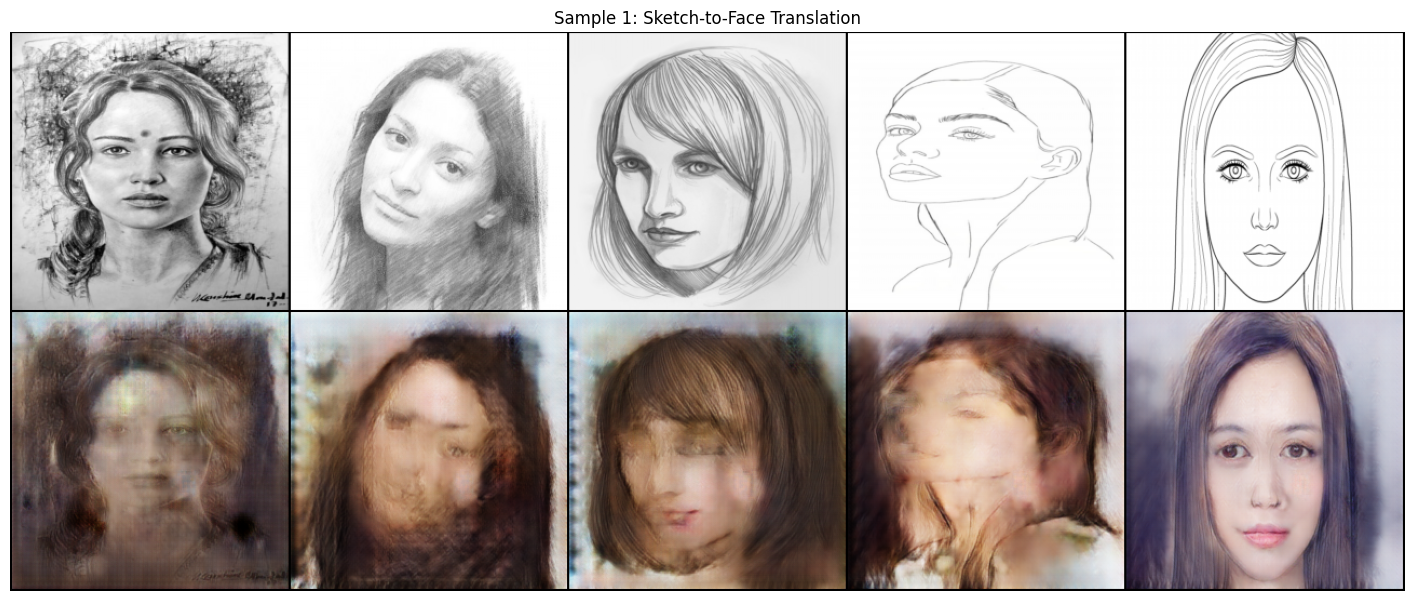

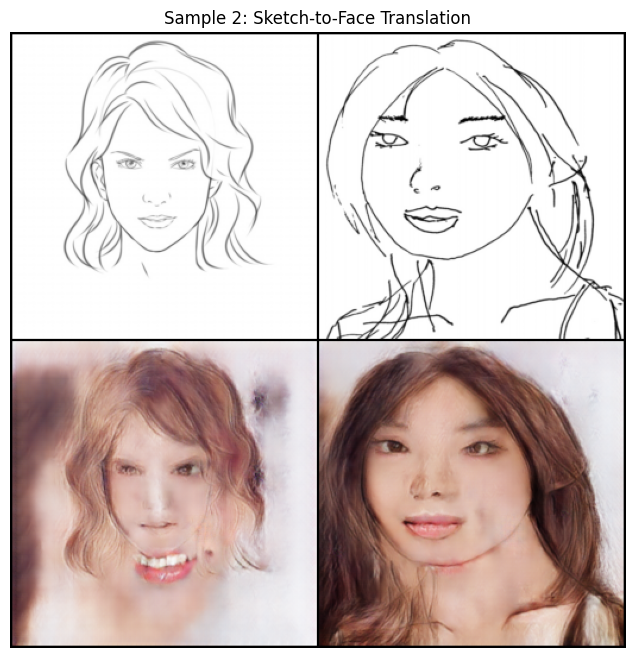

In [23]:
_ = trainer.test(model, datamodule=dm)

---

## Predict Image

In [24]:
predictions = trainer.predict(model, datamodule=dm)

Predicting: |          | 0/? [00:00<?, ?it/s]

Number of images generated: 664.


In [25]:
output_dir = '/kaggle/working/generate'
os.makedirs(output_dir, exist_ok=True)

for i, prediction_batch in enumerate(predictions):
    for j, tensor_image in enumerate(prediction_batch):
        img_filename = f'image_{i*8 + j}.png'
        img_filepath = os.path.join(output_dir, img_filename)
        #print(tensor_image.unsqueeze(0).size())
        save_image(tensor_image.detach().cpu() * 0.5 + 0.5, img_filepath)

In [26]:
from pytorch_gan_metrics import get_fid_from_directory, get_inception_score, get_fid, get_inception_score_from_directory
IS, IS_std = get_inception_score_from_directory("/kaggle/working/generate")
IS, IS_std

Downloading: "https://github.com/w86763777/pytorch-gan-metrics/releases/download/v0.1.0/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 283MB/s]


(1.7361141147561596, 0.057384797485719084)